# MTH/CMSE 314
# IC07: Transformations I
### <p style="text-align: right;"> &#9989; **Mikel Good** </p>

#### Goals
- Finding the image of a vector under a transformation.
- Determining whether a vector is in the range of a transformation.
- Understanding and working with fundamental geometric transformations.
- Creating more complicated transformations by composition.

<img alt="Alternative visual representation showing how the four Fundamental Subspaces spaces map to each other" src="https://upload.wikimedia.org/wikipedia/commons/4/4c/KerIm_2015Joz_L2.png" width="40%">

In [39]:
import numpy as np
import sympy as sym

---
## 1. Practice on transformations

<font color='blue'>**Problem (BY HAND)**. Let $T$ be the transformation $T(x)=Ax$, where $A=\begin{bmatrix} 1&2\\-1&3\end{bmatrix}$. Answer the following questions.\
    (a) Find where $T$ maps the vector $\begin{bmatrix} -5\\4\end{bmatrix}$.

<font size=+3>&#9998;</font> _put your answer here_

<font color='blue'> (b) Find the vector $x$ that has $T(x)=\begin{bmatrix} -6\\-14\end{bmatrix}$.

<font size=+3>&#9998;</font> _put your answer here_ (solve a system)

---

<font color='blue'>&#9989;**Do this**. Let $T$ be the transformation $T(x)=Mx$. Find the matrix $M=\begin{bmatrix} a&b\\c&d\end{bmatrix}$ such that $T$ maps $\begin{bmatrix} -1\\2\end{bmatrix}$ to $\begin{bmatrix} -7\\0\end{bmatrix}$ and $\begin{bmatrix} 3\\-8\end{bmatrix}$ to $\begin{bmatrix} 27\\-2\end{bmatrix}$.

In [2]:
#put your answer here (solve two systems)
AB = np.array([
    [-1, 2, -7],
    [3, -8, 27]
])

CD = np.array([
    [-1, 2, 0],
    [3, -8, -2]
])

In [3]:
sym.Matrix(AB).rref()[0]

Matrix([
[1, 0,  1],
[0, 1, -3]])

In [4]:
sym.Matrix(CD).rref()[0]

Matrix([
[1, 0, 2],
[0, 1, 1]])

a = 1, b = -3, c = 2, d = 1

---

<font color='blue'>&#9989;**Problem (BY HAND)**. By looking at your notes, write down the linear transforms that represent: 
    
 <font color='blue'>   (i) rotation by 90 degrees. 
    
 <font color='blue'>   (ii) reflection through x-axis. 
     
 <font color='blue'>  (iii) horizontal shear (k=2) 
     
 <font color='blue'>  (iv) scaling by 3

<font size=+3>&#9998;</font> _Import a photo with your calculations or type in Latex._

----

## 2. Affine transforms in 2D
In this section, we are going to explore different types of transformation matrices. The following code is designed to demonstrate the properties of some different transformation matrices in $\mathbb{R}^2$.

**&#9989;<font color=blue>Do this:</font>** Review and run the two cells below.

In [5]:
#Some python packages we will be using
%matplotlib inline
import numpy as np
import matplotlib.pylab as plt
from mpl_toolkits.mplot3d import Axes3D # Lets make 3D plots
import numpy as np
import sympy as sym
sym.init_printing(use_unicode=True) # Trick to make matrixes look nice in jupyter
import copy

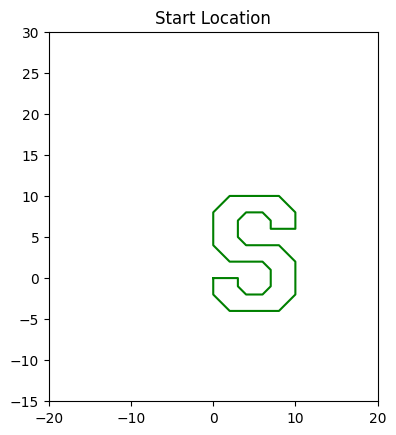

In [6]:
# Define some points
x = [0.0,  0.0,  2.0,  8.0, 10.0, 10.0, 8.0, 4.0, 3.0, 3.0, 4.0, 6.0, 7.0, 7.0, 10.0, 
     10.0,  8.0,  2.0, 0.0, 0.0, 2.0, 6.0, 7.0,  7.0,  6.0,  4.0,  3.0, 3.0, 0.0]
y = [0.0, -2.0, -4.0, -4.0, -2.0,  2.0, 4.0, 4.0, 5.0, 7.0, 8.0, 8.0, 7.0, 6.0,  6.0,
     8.0, 10.0, 10.0, 8.0, 4.0, 2.0, 2.0, 1.0, -1.0, -2.0, -2.0, -1.0, 0.0, 0.0]
con = [ 1.0 for i in range(len(x))] 

p = np.matrix([x,y])


#mp = p.copy()
mp = copy.deepcopy(p)

#Plot Points
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green');
plt.axis('scaled');
plt.axis([-20,20,-15,30]);
plt.title('Start Location');

---
<font color='blue'> **Example 1: Scaling transformation, $S$**. 

**&#9989;<font color=blue>Task:</font>** Try different scale values in the following plot and get different results.

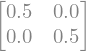

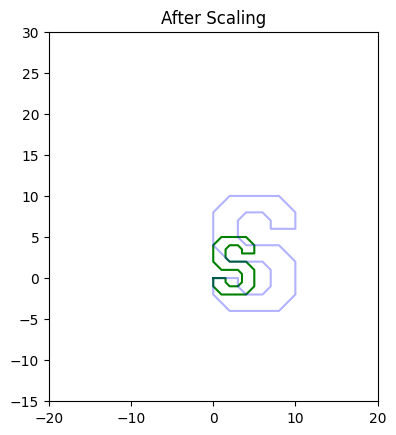

In [7]:
#Example Scaling Matrix

#Define Matrix
scale = 0.5  #The amount that coordinates are scaled.
S = np.matrix([[scale,0], [0,scale]])

#Apply matrix

mp = p.copy()
mp = S*mp

#Plot points after transform
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green')
plt.axis('scaled');
plt.axis([-20,20,-15,30]);
#plt.axis('equal');
plt.title('After Scaling')
# plt.plot([p[0,14],mp[0,14]],[p[1,14],mp[1,14]], color='blue');

#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

sym.Matrix(S)

---
<font color='blue'> **Example 2: Reflection transformation, $Re$**. 

**&#9989;<font color=blue>Task:</font>** Try reflecting across the $x$-axis instead.

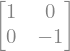

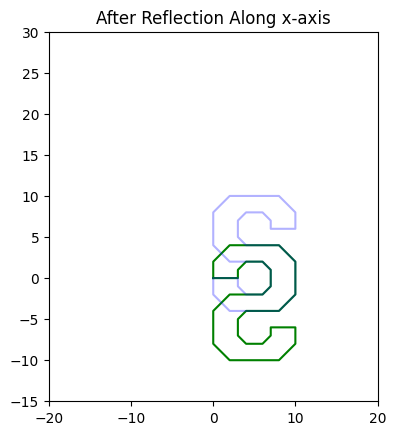

In [8]:
#Example Reflection Matrix

#Define Matrix
Re = np.matrix([[1,0],[0,-1]]) ## Makes all x-values opposite so it reflects about the y-axis.

#Apply matrix

mp = p.copy()

mp = Re*mp

#Plot points after transform
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green')
plt.axis('scaled');
plt.axis([-20,20,-15,30]);
plt.title('After Reflection Along x-axis')


#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

sym.Matrix(Re)

---
<font color='blue'> **Example 3: Rotation Matrix, $R$**. 

**&#9989;<font color=blue>Task:</font>** Try rotating for different angles.

We can rotate these points around the origin by using the following simple set of equations:

$$ x \cos(\theta) - y \sin(\theta) = x_{\text{rotated}} $$
$$ x \sin(\theta) + y \cos(\theta) = y_{\text{rotated}} $$

This can be rewritten in the following matrix form:

$$
\left[
\begin{matrix}
    \cos(\theta) & -\sin(\theta) \\ 
    \sin(\theta) & \cos(\theta)
\end{matrix}
\right] 
\left[
\begin{matrix}
    x \\
    y
\end{matrix}
\right] 
=
\left[
\begin{matrix}
    x_{\text{rotated}}\\ 
    y_{\text{rotated}}
\end{matrix}
\right]
$$

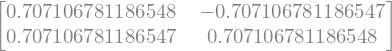

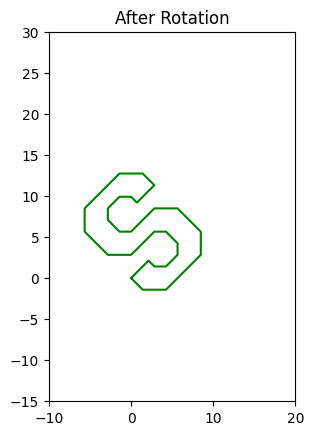

In [9]:
#Example Rotation Matrix

#Define Matrix
degrees = 45
theta = degrees * np.pi / 180  ##Make sure to always convert from degrees to radians. 

# Rotates the points 45 degrees counterclockwise.
R = np.matrix([[np.cos(theta),-np.sin(theta)],[np.sin(theta), np.cos(theta)]]) 

#Apply matrix
mp = p.copy()

mp = R*mp

#Plot points after transform
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green')
plt.axis('scaled')
plt.axis([-10,20,-15,30])
plt.title('After Rotation')

#Uncomment the next line if you want to see the original.
# plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

sym.Matrix(R)

**&#9989;<font color=blue>Task:</font>** Run the next cell to apply the same fixed rotation repeatedly and analyze the resulting pattern.

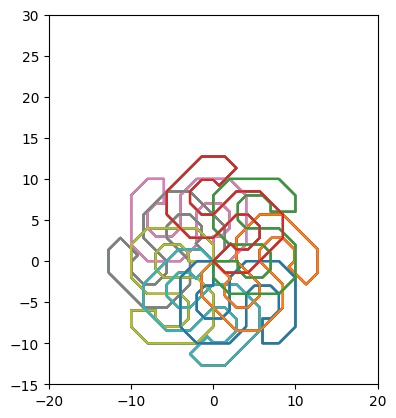

In [10]:
points = np.matrix([x,y])
rot=R*points


# Apply R and plot 8 times
for i in range(0,64):
    rot = R * rot
    plt.plot(rot[0].T,rot[1].T);

#plt.axis('equal');
plt.axis('scaled');
plt.axis([-20,20,-15,30]);

---
<font color='blue'> **Example 4: Shear Transformations, $SHx$ and $SHy$**. 

**&#9989;<font color=blue>Task:</font>** Experiment with different values of ``shx`` to see its effect.

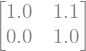

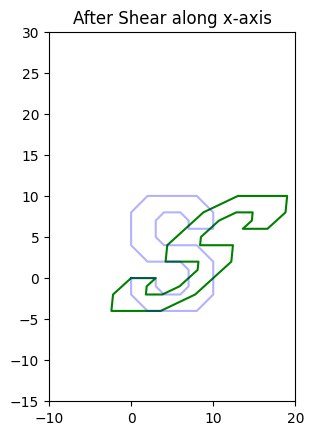

In [11]:
#Example Shear Matrix

#Define Matrix
shx=1.1 # shear in the x-direction
SHx =   np.matrix([[1,shx], [0,1]])

#Apply matrix
mp = p.copy()

mp = SHx*mp

#Plot points after transform
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green')
plt.axis('scaled')
plt.axis([-10,20,-15,30])
plt.title('After Shear along x-axis')

#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

sym.Matrix(SHx)

**&#9989;<font color=blue>Task:</font>** Now, modify the code above to make the shear along the $y$-axis instead. Hint: You only need to modify `shx` and a little bit of the matrix to make it work. To avoid confusion call the new matrix `SHy` and the variable `shy`.

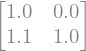

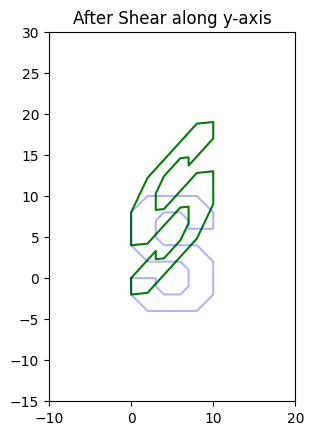

In [13]:
#Put your answer here

#Define Matrix
shy=1.1 # shear in the x-direction
SHy =   np.matrix([[1,0], [shy,1]])

#Apply matrix
mp = p.copy()

mp = SHy*mp

#Plot points after transform
plt.plot(mp[0,:].tolist()[0],mp[1,:].tolist()[0], color='green')
plt.axis('scaled')
plt.axis([-10,20,-15,30])
plt.title('After Shear along y-axis')

#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

sym.Matrix(SHy)

---
<font color='blue'> **Example 5: Translation Transformation, $Tr$**. 

**&#9989;<font color=blue>Task:</font>** Try translating for different values of `dx` and `dy` and see the results.

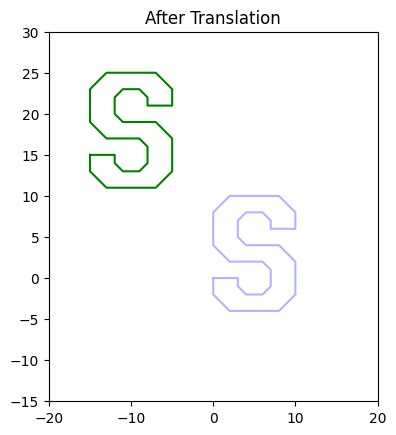

In [18]:
#import sympy as Sym


#Define Matrix
dx = -15  #The amount shifted in the x-direction
dy = 15 #The amount shifted in the y-direction

mp = p.copy()

Tr=np.array([[dx]*mp.shape[1],[dy]*mp.shape[1]])

T=mp+Tr

#Plot points after transform
plt.plot(T[0,:].tolist()[0],T[1,:].tolist()[0], color='green')
#plt.axis('equal');
plt.axis('scaled');
plt.axis([-20,20,-15,30]);
plt.title('After Translation')

#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

---
## 3. Combining Transforms

Consider the five transformation matrices from section 2 above, `R`, `S`, `Re`, `SHx`, and `SHy`.

**&#9989;<font color=blue>Task:</font>** <font color=blue> Construct a ($2 \times 2$) transformation Matrix (called `M`) which combines these five transforms into a single matrix. You can choose different orders for these six matrices, then compare your result with your teammates'. 

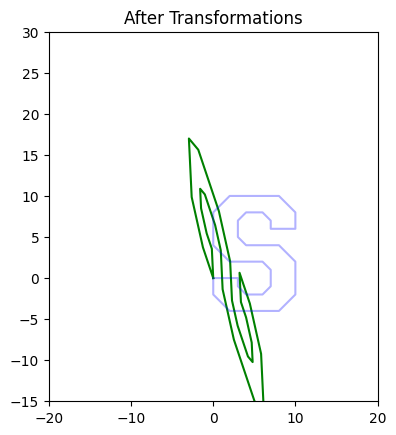

In [38]:
scale = 0.8
S = np.matrix([[scale,0], [0,scale]])

Re = np.matrix([[1,0],[0,-1]])

degrees = 45
theta = degrees * np.pi / 180
R = np.matrix([[np.cos(theta),-np.sin(theta)],
               [np.sin(theta), np.cos(theta)]])

shx = 1.1
SHx = np.matrix([[1, shx], [0, 1]])

shy = 1.1
SHy = np.matrix([[1, 0], [shy, 1]])

M = R @ SHy @ SHx @ Re @ S

mp = M @ p

plt.plot(mp[0,:].tolist()[0], mp[1,:].tolist()[0], color='green')
plt.axis('scaled')
plt.axis([-20,20,-15,30])
plt.title('After Transformations')

plt.plot(p[0,:].tolist()[0], p[1,:].tolist()[0], color='blue', alpha=0.3)
plt.show()

<font color=blue>**Question:**</font> Did you get the same result as the rest of your group-mates? You can compare the matrix `M` to see the difference. If not, can you explain why it happens?

<font size=+3>&#9998;</font>  Depending on the order of the operations, the result will be different.

---
**&#9989;<font color=blue>Task:</font>** Complete the block of code below to create a function `transformation` that first rotates the points `p` by 45 degrees, then scales them by 2, then translates them by $dx = -12$, $dy = 15$ and finally reflects them about the x-axis!

In [44]:
#Put your answer here

def transformation(p): #p = np.array([x,y])
    degrees = 45
    theta = degrees * np.pi / 180
    R = np.matrix([[np.cos(theta),-np.sin(theta)],
               [np.sin(theta), np.cos(theta)]])
    S=  np.matrix([[2,0], [0, 2]])
    Tr= np.matrix([[-12]*mp.shape[1],[15]*mp.shape[1]]) #translation
    Re = np.matrix([[1,0],[0,-1]])
    W_xy = Re@(S@R*p+ Tr) #combine all
    W = W_xy #rename the transform W_xy to W in order to simplify the notation; Notice that W is not a matrix, but a transform
    return W

---
**&#9989;<font color=blue>Task:</font>** Apply the function to the list of points we have from the beginning (`p = np.array([x,y])`). Then complete the code to plot the new graph.

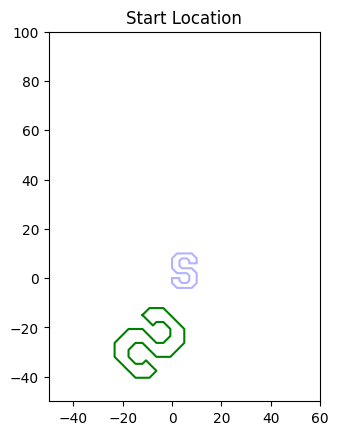

In [46]:
#Plot combined transformed points
W = transformation(p.copy())

plt.plot(W[0,:].tolist()[0],W[1,:].tolist()[0], color='green');
plt.axis('scaled');
plt.axis([-50,60,-50,100]);
plt.title('Start Location');

#Uncomment the next line if you want to see the original.
plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='blue',alpha=0.3);

---
## 4. An Interactive Example
**&#9989;<font color=blue>Task:</font>** First, run the following block of code.

In [56]:
from ipywidgets import interact,interact_manual

def affine_image(angle=0.0,scale=1.0,dx=0,dy=0, shx=0, shy=0):
    theta = -angle/180  * np.pi
    
    
    plt.plot(p[0,:].tolist()[0],p[1,:].tolist()[0], color='green')
    
    S = np.matrix([[scale,0], [0,scale] ])
    SH1 = np.matrix([[1,shx], [0,1]])
    SH2 = np.matrix([[1,0], [shy,1]])
    T2 = np.array([[dx]*mp.shape[1],[dy]*mp.shape[1]])
    R = np.matrix([[np.cos(theta),-np.sin(theta)],[np.sin(theta), np.cos(theta)]])
    
    # Create transform:
    FT = SH2@SH1@R@S;
    
    p2 =  FT*p+T2;
    
    #Plot Output
    plt.plot(p2[0,:].tolist()[0],p2[1,:].tolist()[0], color='black')
    plt.axis('equal')
    plt.axis([-20,30,-15,15])
    return sym.Matrix(FT)

---
**&#9989;<font color=blue>Task:</font>**  Second, modify the following code at free will to test different values of scaling,rotating, etc...
The following command might be slow on some computers.

interactive(children=(IntSlider(value=0, description='angle', max=180, min=-180), FloatSlider(value=1.0, descr…

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


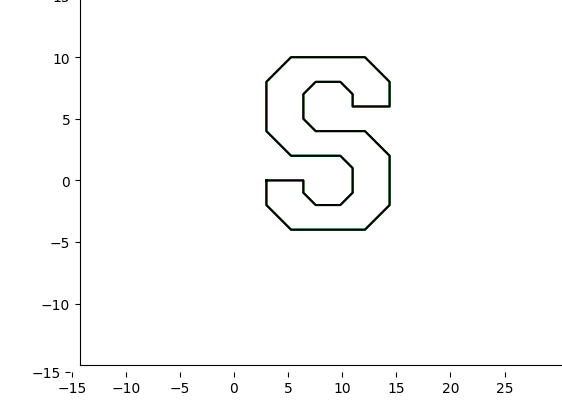

In [57]:
interact(affine_image, angle=(-180,180), scale_manual=(0.01,2), dx=(-5,15,0.5), dy=(-15,15,0.5), shx = (-1,1,0.1), shy = (-1,1,0.1)); 

---
**&#9989;<font color=blue>Task:</font>**  Use the above interactive environment to see if you can figure out the transformation matrix to make the following image. If the image does not load, double-click the cell, copy the URL in your browser, and then work.

<img src="https://lh6.googleusercontent.com/_0-jr5Z0DQzqVM3TD3Xa3QWC43PBT6ru5M-B-_7dfbib2SSvkNkxtioBFaU__jTvEJMMG9SAVg=w380">

**<font color=blue>Question:</font>** What were the input values?

The widget was not working properly, but just by looking at it, it appears to be rotated 180 degrees, displaced in the y direction, and then sheared in the x direction.

r = 180

scale = 1

dx = 0

dy = -10

shx = 1.3

shy = 0

---
## 5. Affine Transforms in 3D
Here we will briefly explore the analogs of what we did in 2D.

### Rotation about the $x$-axis

$$ 
\left[ \begin{matrix}
    x' \\
    y' \\
    z' 
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    1 & 0 & 0 \\
    0 & \cos(q) & -\sin(q)   \\
    0 & \sin(q) & \cos(q) \\
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x \\
    y \\
    z 
 \end{matrix}
\right] 
$$ 



### Rotation about the $y$-axis
$$ 
\left[ \begin{matrix}
    x' \\
    y' \\
    z'
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    \cos(q) & 0 &\sin(q)  \\
    0 & 1 & 0 \\
    -\sin(q) & 0 &\cos(q)  \\
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x \\
    y \\
    z 
 \end{matrix}
\right] 
$$ 



### Rotation about the $z$-axis

$$ 
\left[ \begin{matrix}
    x' \\
    y' \\
    z' \\
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    \cos(q) & -\sin(q) & 0  \\
    \sin(q) & \cos(q) & 0 \\
    0 & 0 & 1  
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x \\
    y \\
    z
 \end{matrix}
\right] 
$$ 

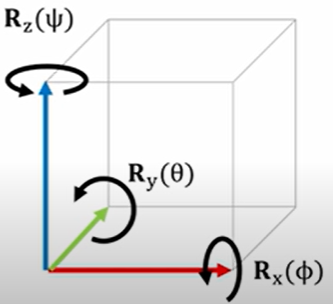



### Scaling by $s>0$
$$ 
\left[ \begin{matrix}
    x' \\
    y' \\
    z' \\
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    s & 0 & 0  \\
    0 & s & 0 \\
    0 & 0 & s  
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x \\
    y \\
    z
 \end{matrix}
\right] 
$$

### Reflection about $xy$-plane
$$ 
\left[ \begin{matrix}
    x' \\
    y' \\
    z' \\
 \end{matrix}
\right] 
=
\left[ \begin{matrix}
    1 & 0 & 0  \\
    0 & 1 & 0 \\
    0 & 0 & -1  
 \end{matrix}
\right] 
\left[ \begin{matrix}
    x \\
    y \\
    z
 \end{matrix}
\right] 
$$

**&#9989;<font color=blue>Task:</font>** Find the matrix of the 3D transform that represents a rotation about $y$-axis by 30 degrees, followed by a reflection about $yz$-plane, and a scaling by 5. 

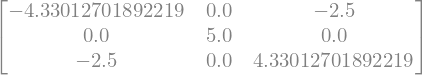

In [59]:
#put your answer here
theta = 30 * np.pi/180
rot_y = np.array([
    [np.cos(theta), 0, np.sin(theta)],
    [0, 1, 0],
    [-np.sin(theta), 0, np.cos(theta)]
])

ref_yz = np.array([
    [-1, 0, 0],
    [0, 1, 0],
    [0, 0, 1]
])

s_5 = np.array([
    [5, 0, 0],
    [0, 5, 0],
    [0, 0, 5]
])

res = s_5 @ ref_yz @ rot_y
sym.Matrix(res)

---
## Congratulations, you're done!
## Before you close or submit this In-Class Assignment, please make sure of a few things:
- Did you save the file? `Ctrl + S` like everything else works!
- Is the file in correct format? You need to submit this file in `.pdf` format. To do so, `Ctrl + P` and `Save as pdf` (on Windows) or `command + P` in mac.
- If that does not work, please Google "ipynb to pdf converter" and that should do the job.
- Are the pictures/images rendering correctly in the `.pdf` format?
- If the images are not rendering, you could also use this command in a cell:

`from IPython.display import display, Image`

`display(Image(filename="a.jpg", height=400, width=400))`

THIS ONLY WORKS WITH JPGS.
- If this fails, save it as a pdf and merge it with this pdf, perhaps using an online tool (google it!)

- Please double check the contents of the file. One of the most common errors students make is submission of an empty file!